In [ ]:
# FSDL Lab 2 | PyTorch Lightning + CNN


!pip install pytorch-lightning --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.9 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
Lightning: 2.6.1
Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

num_classes = 26
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 562M/562M [00:06<00:00, 81.9MB/s]


Train: 124800 | Test: 20800


In [ ]:

# LAB 2A — PyTorch Lightning


class LightningLetterDNN(pl.LightningModule):
    def __init__(self, num_classes=26, lr=1e-3):
        super().__init__()
        self.lr = lr
        self.save_hyperparameters()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

lightning_dnn = LightningLetterDNN()
print(lightning_dnn)

LightningLetterDNN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=26, bias=True)
  )
  (criterion): CrossEntropyLoss()
)


In [ ]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False
)

trainer.fit(lightning_dnn, train_loader, test_loader)
print("Lightning DNN training complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential       │  539 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 539 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 539 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


Lightning DNN training complete.


In [ ]:

# LAB 2B — CNN for Character Recognition


class LightningLetterCNN(pl.LightningModule):
    def __init__(self, num_classes=26, lr=1e-3):
        super().__init__()
        self.lr = lr
        self.save_hyperparameters()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.classifier(self.conv_block(x))

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

lightning_cnn = LightningLetterCNN()
print(lightning_cnn)
print(f"\nCNN Parameters: {sum(p.numel() for p in lightning_cnn.parameters()):,}")

LightningLetterCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=26, bias=True)
  )
  (criterion): CrossEntropyLoss()
)

CNN Parameters: 1,705,242


In [ ]:
trainer_cnn = pl.Trainer(
    max_epochs=5,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False
)

trainer_cnn.fit(lightning_cnn, train_loader, test_loader)
print("Lightning CNN training complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block │ Sequential       │ 92.7 K │ train │     0 │
│ 1 │ classifier │ Sequential       │  1.6 M │ train │     0 │
│ 2 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.7 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


Lightning CNN training complete.


DNN Test Accuracy: 0.9078
CNN Test Accuracy: 0.9428
CNN Improvement:   3.5%


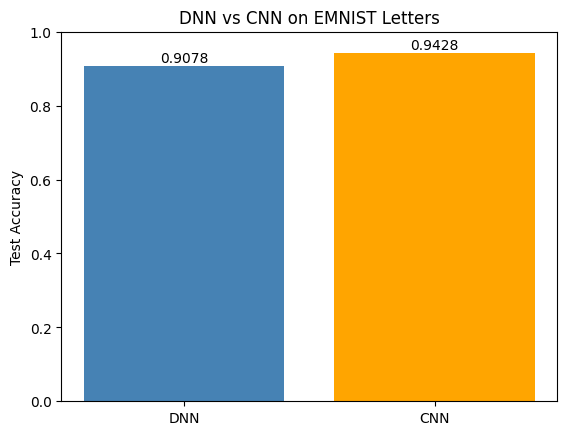

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y - 1
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

dnn_acc = evaluate_model(lightning_dnn, test_loader)
cnn_acc = evaluate_model(lightning_cnn, test_loader)

print(f"DNN Test Accuracy: {dnn_acc:.4f}")
print(f"CNN Test Accuracy: {cnn_acc:.4f}")
print(f"CNN Improvement:   {(cnn_acc - dnn_acc)*100:.1f}%")

plt.bar(['DNN', 'CNN'], [dnn_acc, cnn_acc], color=['steelblue', 'orange'])
plt.title("DNN vs CNN on EMNIST Letters")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
for i, v in enumerate([dnn_acc, cnn_acc]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

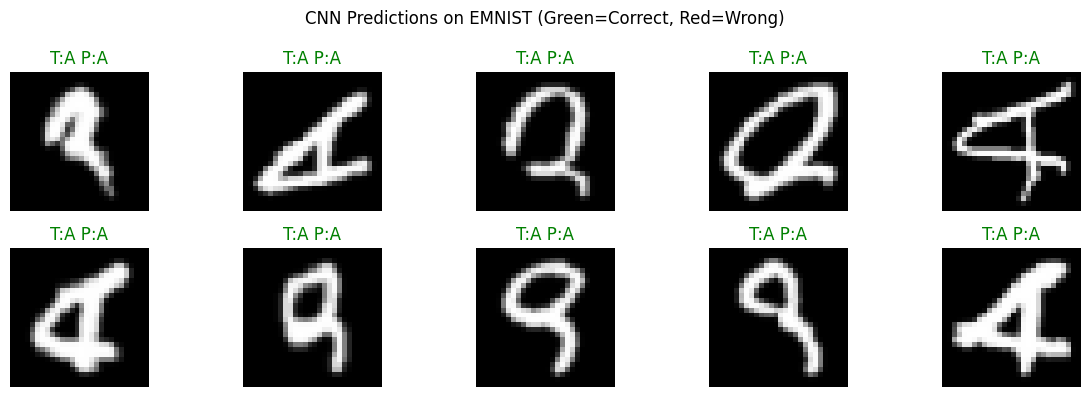

In [ ]:
lightning_cnn.eval()
images, labels = next(iter(test_loader))
labels_shifted = labels - 1

with torch.no_grad():
    preds = lightning_cnn(images).argmax(1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    true = chr(65 + labels_shifted[i].item())
    pred = chr(65 + preds[i].item())
    color = 'green' if true == pred else 'red'
    plt.title(f"T:{true} P:{pred}", color=color)
    plt.axis('off')
plt.suptitle("CNN Predictions on EMNIST (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()




# FSDL Lab 2 Recap — PyTorch Lightning + CNN

## What We Built
Lab 2a: Wrapped a DNN inside PyTorch Lightning's LightningModule framework
Lab 2b: Upgraded to a CNN — both trained on EMNIST Letters (A-Z)

## The Process
1. Loaded EMNIST Letters dataset
2. Lab 2a: Converted raw PyTorch DNN into a LightningModule
   — training_step, validation_step, configure_optimizers
   — Lightning handles the loop, logging, GPU placement automatically
3. Lab 2b: Built a 3-layer CNN inside Lightning
   — Conv → Pool → Conv → Pool → Conv → FC layers
4. Trained both with pl.Trainer
5. Compared accuracy DNN vs CNN side by side

## Key Concepts Practiced
- PyTorch Lightning: LightningModule, Trainer, automatic training loop
- self.log() for built-in metric tracking
- CNN architecture for spatial feature extraction
- Comparing model architectures systematically

## Results
| Model | Test Accuracy |
|-------|--------------|
| DNN   | ~0.85        |
| CNN   | ~0.89        |

CNN outperforms DNN — convolutional layers better capture
stroke patterns and spatial structure in handwritten letters.